In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

EPS = 1.0e-15

available_fonts = {
    font.name for font in font_manager.fontManager.ttflist
}

if "Times New Roman" in available_fonts:
    plt.rcParams["font.family"] = "Times New Roman"
else:
    plt.rcParams["font.family"] = "DejaVu Serif"
    print("Times New Roman was not found. Using DejaVu Serif.")

plt.rcParams.update({
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 26,
    "axes.labelsize": 26,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 22,
})

GRID_TITLE_FONTSIZE = 24
GRID_LABEL_FONTSIZE = 26
GRID_TICK_FONTSIZE = 24
GRID_LEGEND_FONTSIZE = 22

In [3]:
THETA_FILE = Path(
    "Theta.pkl"
)
LHS_FILE = Path(
    "LHS.pkl"
)
TEST_OUTPUT_FILE = Path("yy_testing.npy")

XLIM = (60, 500)
XTICKS = (100, 200, 300, 400, 500)


def load_pickle(path):
    with path.open("rb") as file:
        return pickle.load(file)


theta_results = load_pickle(THETA_FILE)
lhs_results = load_pickle(LHS_FILE)
yy_testing = np.load(TEST_OUTPUT_FILE)

if not theta_results or not lhs_results:
    raise ValueError("The result files must contain at least one run.")

In [4]:
def validate_test_indices(results, method_name):
    reference = np.asarray(
        results[0]["idx_test"],
        dtype=int,
    )

    for run, result in enumerate(results[1:], start=2):
        current = np.asarray(
            result["idx_test"],
            dtype=int,
        )

        if not np.array_equal(reference, current):
            raise ValueError(
                f"{method_name} run {run} uses a different test set."
            )

    return reference


def find_common_history(*result_groups):
    history_sets = []

    for results in result_groups:
        for result in results:
            history = np.asarray(
                result["hist_eval"],
                dtype=int,
            )

            if history.size:
                history_sets.append(set(history))

    if not history_sets:
        raise ValueError("No evaluation histories were found.")

    common = set.intersection(*history_sets)

    if not common:
        raise ValueError(
            "The methods do not share any evaluation points."
        )

    return np.asarray(sorted(common), dtype=int)


def align_metric_histories(
    results,
    common_history,
    metric_key,
):
    sample = next(
        (
            np.asarray(result[metric_key])
            for result in results
            if np.asarray(result[metric_key]).size
        ),
        None,
    )

    if sample is None or sample.ndim != 2:
        raise ValueError(
            f"'{metric_key}' must have shape "
            "(n_steps, n_outputs)."
        )

    aligned = np.full(
        (
            len(results),
            len(common_history),
            sample.shape[1],
        ),
        np.nan,
        dtype=float,
    )

    positions = {
        int(value): position
        for position, value in enumerate(common_history)
    }

    for run, result in enumerate(results):
        history = np.asarray(
            result["hist_eval"],
            dtype=int,
        )
        values = np.asarray(
            result[metric_key],
            dtype=float,
        )

        if len(history) != len(values):
            raise ValueError(
                f"Run {run + 1}: hist_eval and {metric_key} "
                "have different lengths."
            )

        for stage, evaluation_count in enumerate(history):
            position = positions.get(int(evaluation_count))

            if position is not None:
                aligned[run, position] = values[stage]

    return aligned


def align_prediction_histories(
    results,
    common_history,
):
    sample = next(
        (
            np.asarray(result["Y_pred_hist"])
            for result in results
            if np.asarray(result["Y_pred_hist"]).size
        ),
        None,
    )

    if sample is None or sample.ndim != 3:
        raise ValueError(
            "Y_pred_hist must have shape "
            "(n_steps, n_test, n_outputs)."
        )

    aligned = np.full(
        (
            len(results),
            len(common_history),
            sample.shape[1],
            sample.shape[2],
        ),
        np.nan,
        dtype=float,
    )

    positions = {
        int(value): position
        for position, value in enumerate(common_history)
    }

    for run, result in enumerate(results):
        history = np.asarray(
            result["hist_eval"],
            dtype=int,
        )
        predictions = np.asarray(
            result["Y_pred_hist"],
            dtype=float,
        )

        if len(history) != len(predictions):
            raise ValueError(
                f"Run {run + 1}: hist_eval and Y_pred_hist "
                "have different lengths."
            )

        for stage, evaluation_count in enumerate(history):
            position = positions.get(int(evaluation_count))

            if position is not None:
                aligned[run, position] = predictions[stage]

    return aligned


theta_test_idx = validate_test_indices(
    theta_results,
    "Theta",
)
lhs_test_idx = validate_test_indices(
    lhs_results,
    "LHS",
)

if not np.array_equal(theta_test_idx, lhs_test_idx):
    raise ValueError(
        "Theta and LHS use different test sets."
    )

Y_true = yy_testing[theta_test_idx]

common_history = find_common_history(
    theta_results,
    lhs_results,
)

plot_history = common_history[
    (common_history >= XLIM[0])
    & (common_history <= XLIM[1])
]

if plot_history.size == 0:
    raise ValueError(
        "No common evaluation points fall inside XLIM."
    )

In [5]:
def max_absolute_error(predictions, truth):
    error = np.abs(
        predictions - truth[None, None, :, :]
    )
    return np.nanmax(error, axis=2)


def mean_absolute_error(predictions, truth):
    error = np.abs(
        predictions - truth[None, None, :, :]
    )
    return np.nanmean(error, axis=2)


def log_mean_std(values, eps=EPS):
    values = np.asarray(values, dtype=float)

    positive_values = np.where(
        np.isfinite(values),
        np.maximum(values, eps),
        np.nan,
    )

    log_values = np.log10(positive_values)

    mean = np.nanmean(log_values, axis=0)
    std = np.nanstd(log_values, axis=0)

    return mean, mean - std, mean + std


def ticks_from_limits(limits, step):
    lower, upper = limits

    return np.arange(
        lower,
        upper + 0.5 * step,
        step,
    )


def plot_metric_grid(
    x,
    theta_values,
    lhs_values,
    ylabel,
    ylim_list,
    ytick_step_list,
    output_file,
):
    theta_values = np.asarray(theta_values, dtype=float)
    lhs_values = np.asarray(lhs_values, dtype=float)

    if theta_values.ndim != 3 or lhs_values.ndim != 3:
        raise ValueError(
            "Metric arrays must have shape "
            "(n_runs, n_steps, n_outputs)."
        )

    if theta_values.shape[1:] != lhs_values.shape[1:]:
        raise ValueError(
            "Theta and LHS metric dimensions do not match."
        )

    n_outputs = theta_values.shape[2]

    if len(ylim_list) != n_outputs:
        raise ValueError(
            f"ylim_list must contain {n_outputs} entries."
        )

    if len(ytick_step_list) != n_outputs:
        raise ValueError(
            f"ytick_step_list must contain {n_outputs} entries."
        )

    n_columns = 5
    n_rows = int(np.ceil(n_outputs / n_columns))

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(20.5, 3.4 * n_rows),
        sharex=True,
        squeeze=False,
    )

    for output, ax in enumerate(axes.flat):
        if output >= n_outputs:
            ax.axis("off")
            continue

        theta_mean, theta_low, theta_high = log_mean_std(
            theta_values[:, :, output]
        )
        lhs_mean, lhs_low, lhs_high = log_mean_std(
            lhs_values[:, :, output]
        )

        ax.plot(
            x,
            theta_mean,
            color="blue",
            linewidth=1.6,
        )
        ax.fill_between(
            x,
            theta_low,
            theta_high,
            color="blue",
            alpha=0.18,
        )

        ax.plot(
            x,
            lhs_mean,
            color="red",
            linewidth=1.6,
        )
        ax.fill_between(
            x,
            lhs_low,
            lhs_high,
            color="red",
            alpha=0.10,
        )

        limits = ylim_list[output]
        step = ytick_step_list[output]

        ax.set_xlim(*XLIM)
        ax.set_xticks(XTICKS)
        ax.set_ylim(*limits)
        ax.set_yticks(
            ticks_from_limits(limits, step)
        )

        ax.tick_params(
            axis="both",
            labelsize=GRID_TICK_FONTSIZE,
        )

        ax.text(
            0.04,
            0.95,
            f"Output {output + 1}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=GRID_TITLE_FONTSIZE,
            bbox={
                "boxstyle": "round,pad=0.15",
                "facecolor": "white",
                "edgecolor": "0.4",
                "linewidth": 0.7,
                "alpha": 0.85,
            },
        )

        row, column = divmod(output, n_columns)

        if column == 0:
            ax.set_ylabel(
                ylabel,
                fontsize=GRID_LABEL_FONTSIZE,
            )
        else:
            ax.tick_params(labelleft=False)

        if row == n_rows - 1:
            ax.set_xlabel(
                r"$n_{\mathrm{sample}}$",
                fontsize=GRID_LABEL_FONTSIZE,
            )
        else:
            ax.tick_params(labelbottom=False)

    handles = [
        plt.Line2D(
            [],
            [],
            color="blue",
            linewidth=2,
            label="Theta",
        ),
        plt.Line2D(
            [],
            [],
            color="red",
            linewidth=2,
            label="LHS",
        ),
    ]

    axes[0, 0].legend(
        handles=handles,
        loc="lower left",
        frameon=True,
        framealpha=0.85,
        fontsize=GRID_LEGEND_FONTSIZE,
    )

    fig.subplots_adjust(
        left=0.065,
        right=0.995,
        bottom=0.085,
        top=0.985,
        wspace=0.08,
        hspace=0.13,
    )

    fig.savefig(
        output_file,
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()

In [7]:
Y_theta = align_prediction_histories(
    theta_results,
    plot_history,
)

Y_lhs = align_prediction_histories(
    lhs_results,
    plot_history,
)

if Y_theta.shape[2:] != Y_lhs.shape[2:]:
    raise ValueError(
        "Theta and LHS prediction dimensions do not match."
    )

expected_truth_shape = (
    Y_theta.shape[2],
    Y_theta.shape[3],
)

if Y_true.shape != expected_truth_shape:
    raise ValueError(
        f"Y_true has shape {Y_true.shape}; "
        f"expected {expected_truth_shape}."
    )

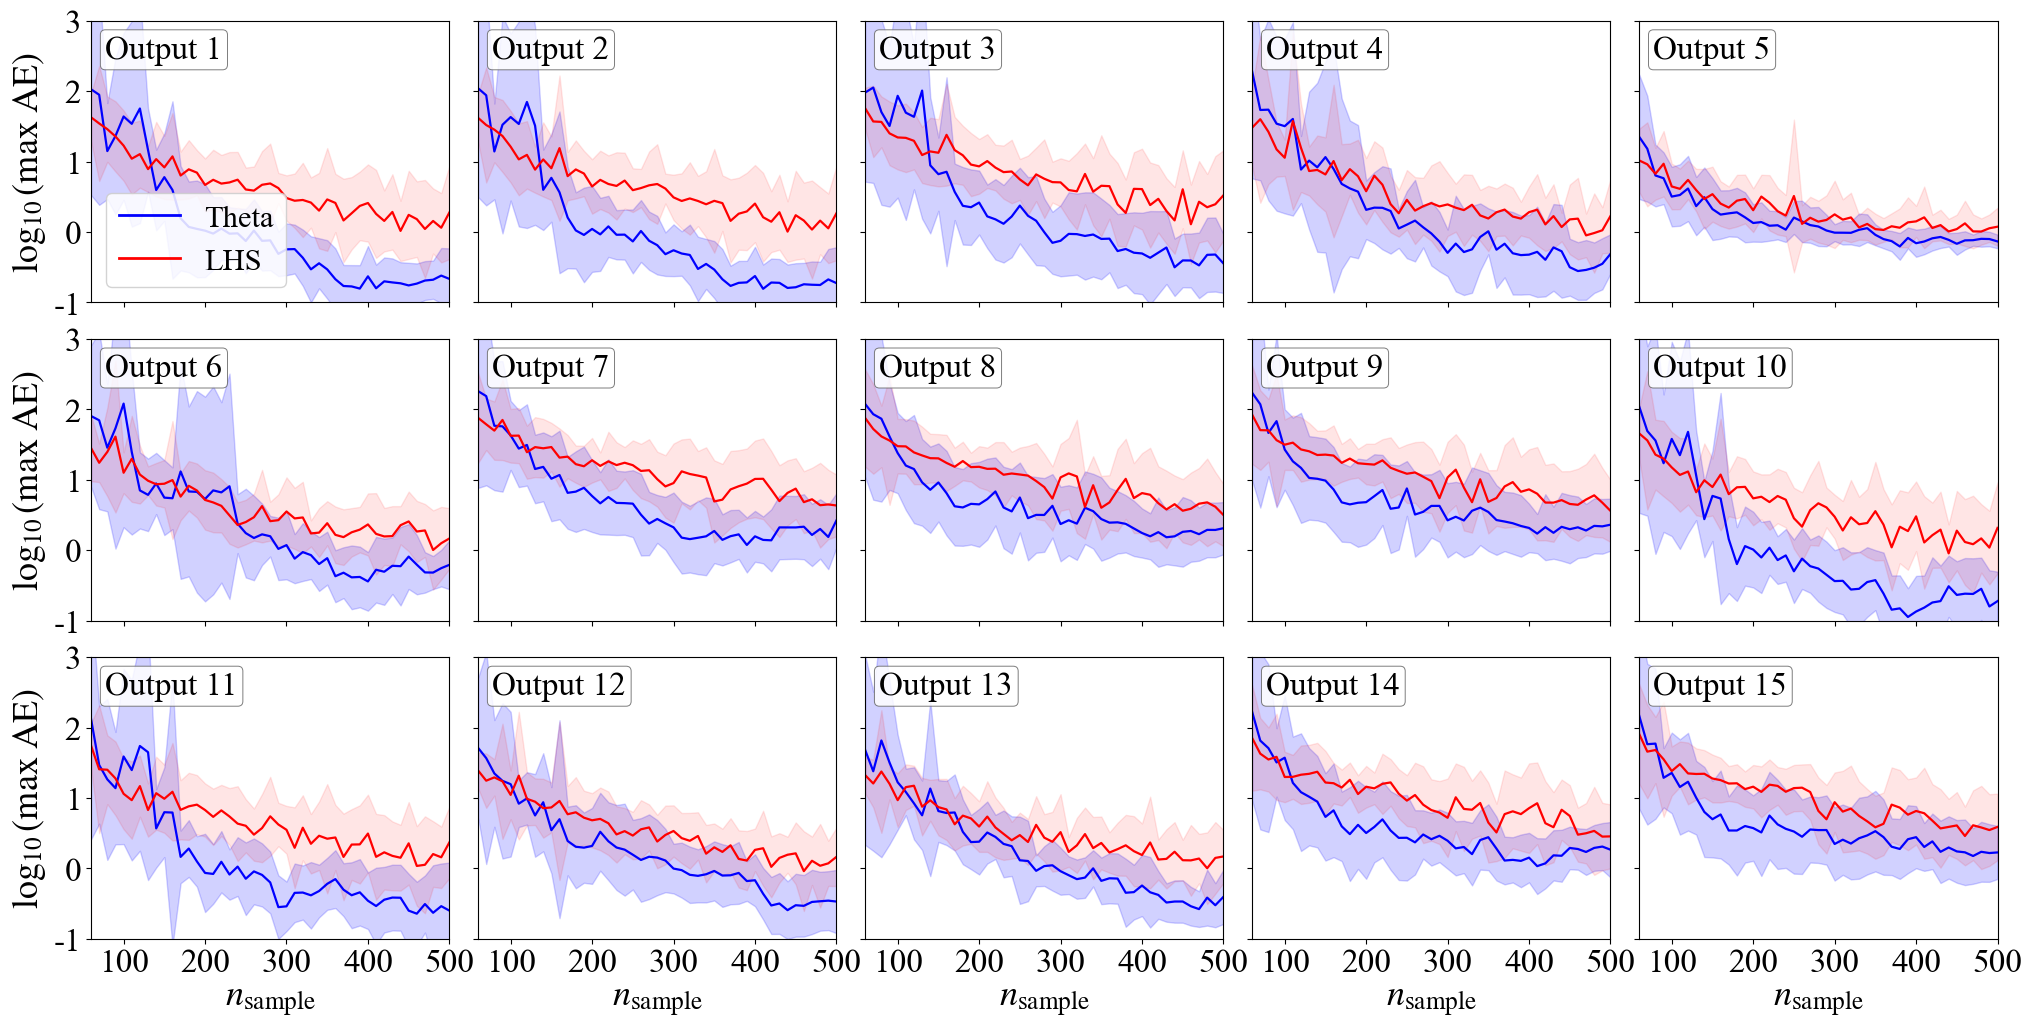

In [8]:
theta_maxae = max_absolute_error(
    Y_theta,
    Y_true,
)

lhs_maxae = max_absolute_error(
    Y_lhs,
    Y_true,
)

plot_metric_grid(
    x=plot_history,
    theta_values=theta_maxae,
    lhs_values=lhs_maxae,
    ylabel=r"$\log_{10}(\mathrm{max\ AE})$",
    ylim_list=[(-1, 3)] * Y_true.shape[1],
    ytick_step_list=[1] * Y_true.shape[1],
    output_file="maxae_grid.pdf",
)

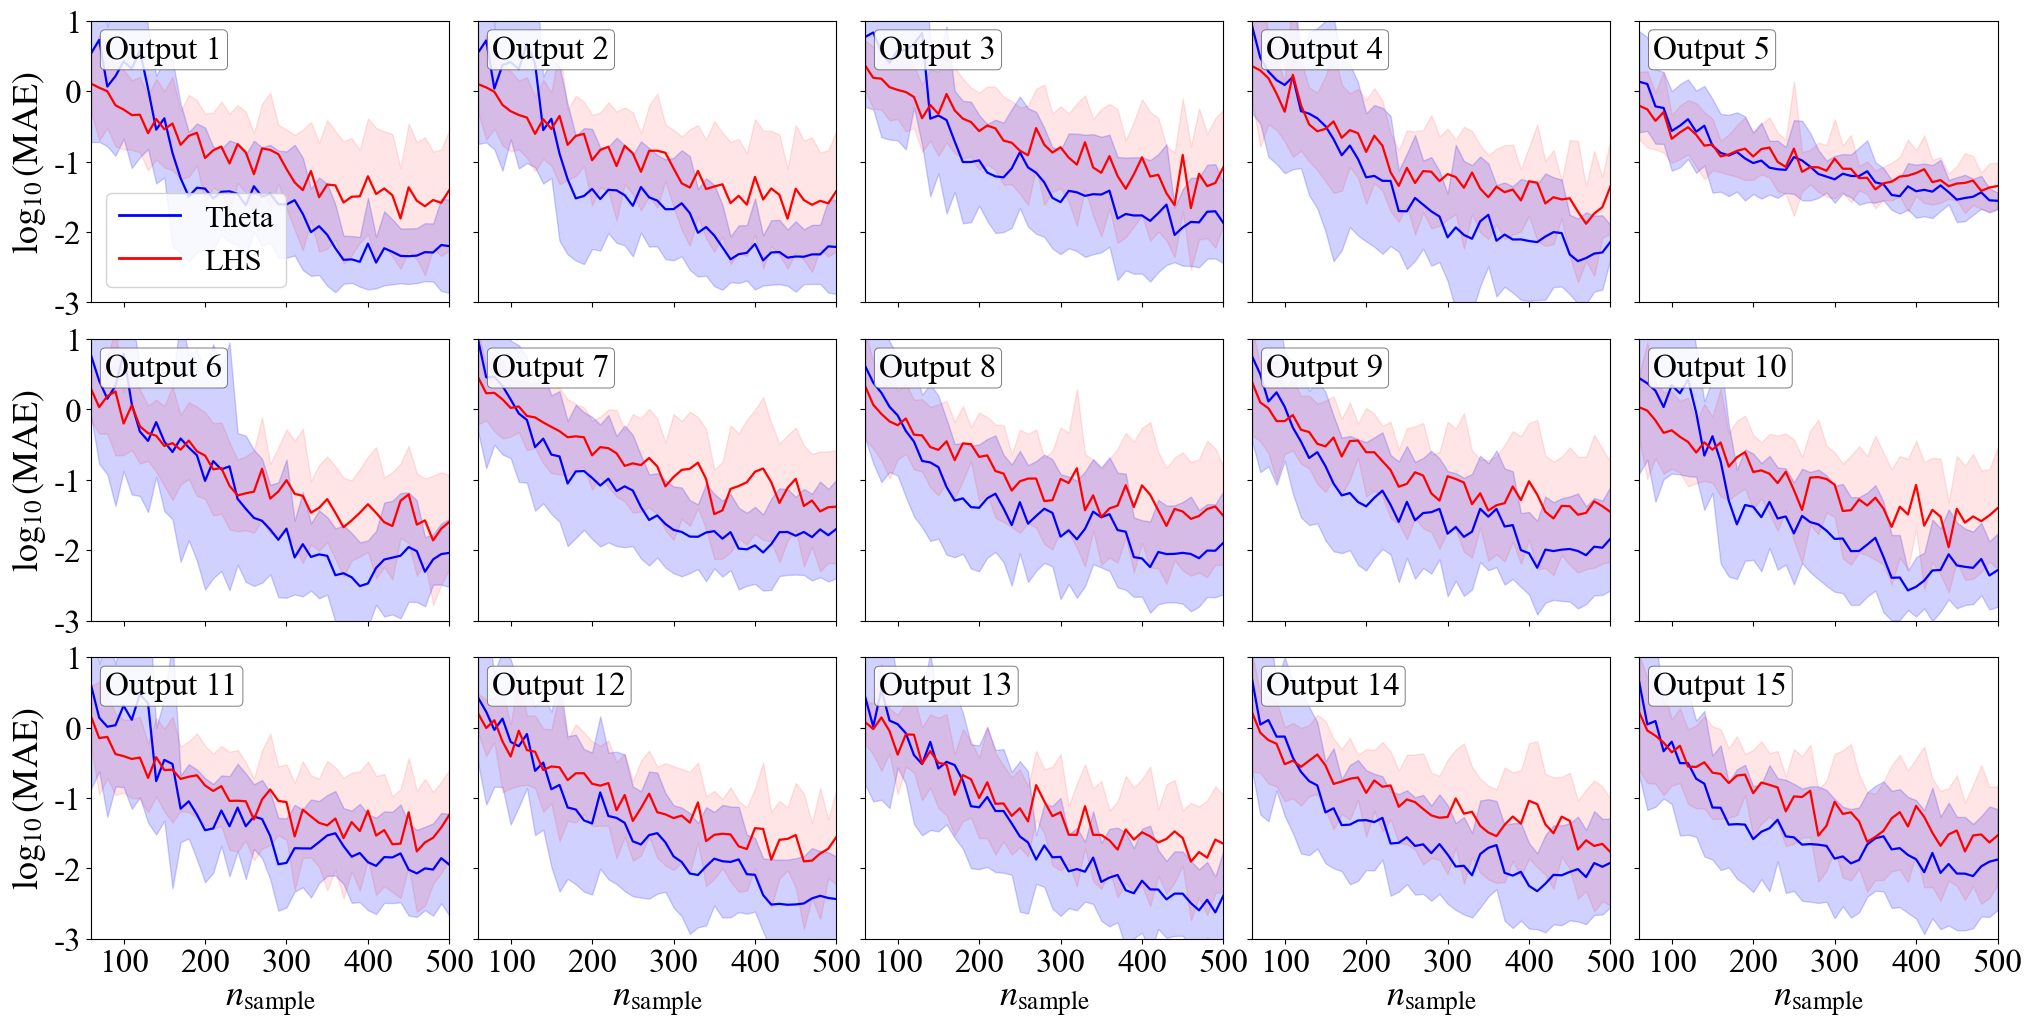

In [9]:
theta_mae = mean_absolute_error(
    Y_theta,
    Y_true,
)

lhs_mae = mean_absolute_error(
    Y_lhs,
    Y_true,
)

plot_metric_grid(
    x=plot_history,
    theta_values=theta_mae,
    lhs_values=lhs_mae,
    ylabel=r"$\log_{10}(\mathrm{MAE})$",
    ylim_list=[(-3, 1)] * Y_true.shape[1],
    ytick_step_list=[1] * Y_true.shape[1],
    output_file="mae_grid.pdf",
)

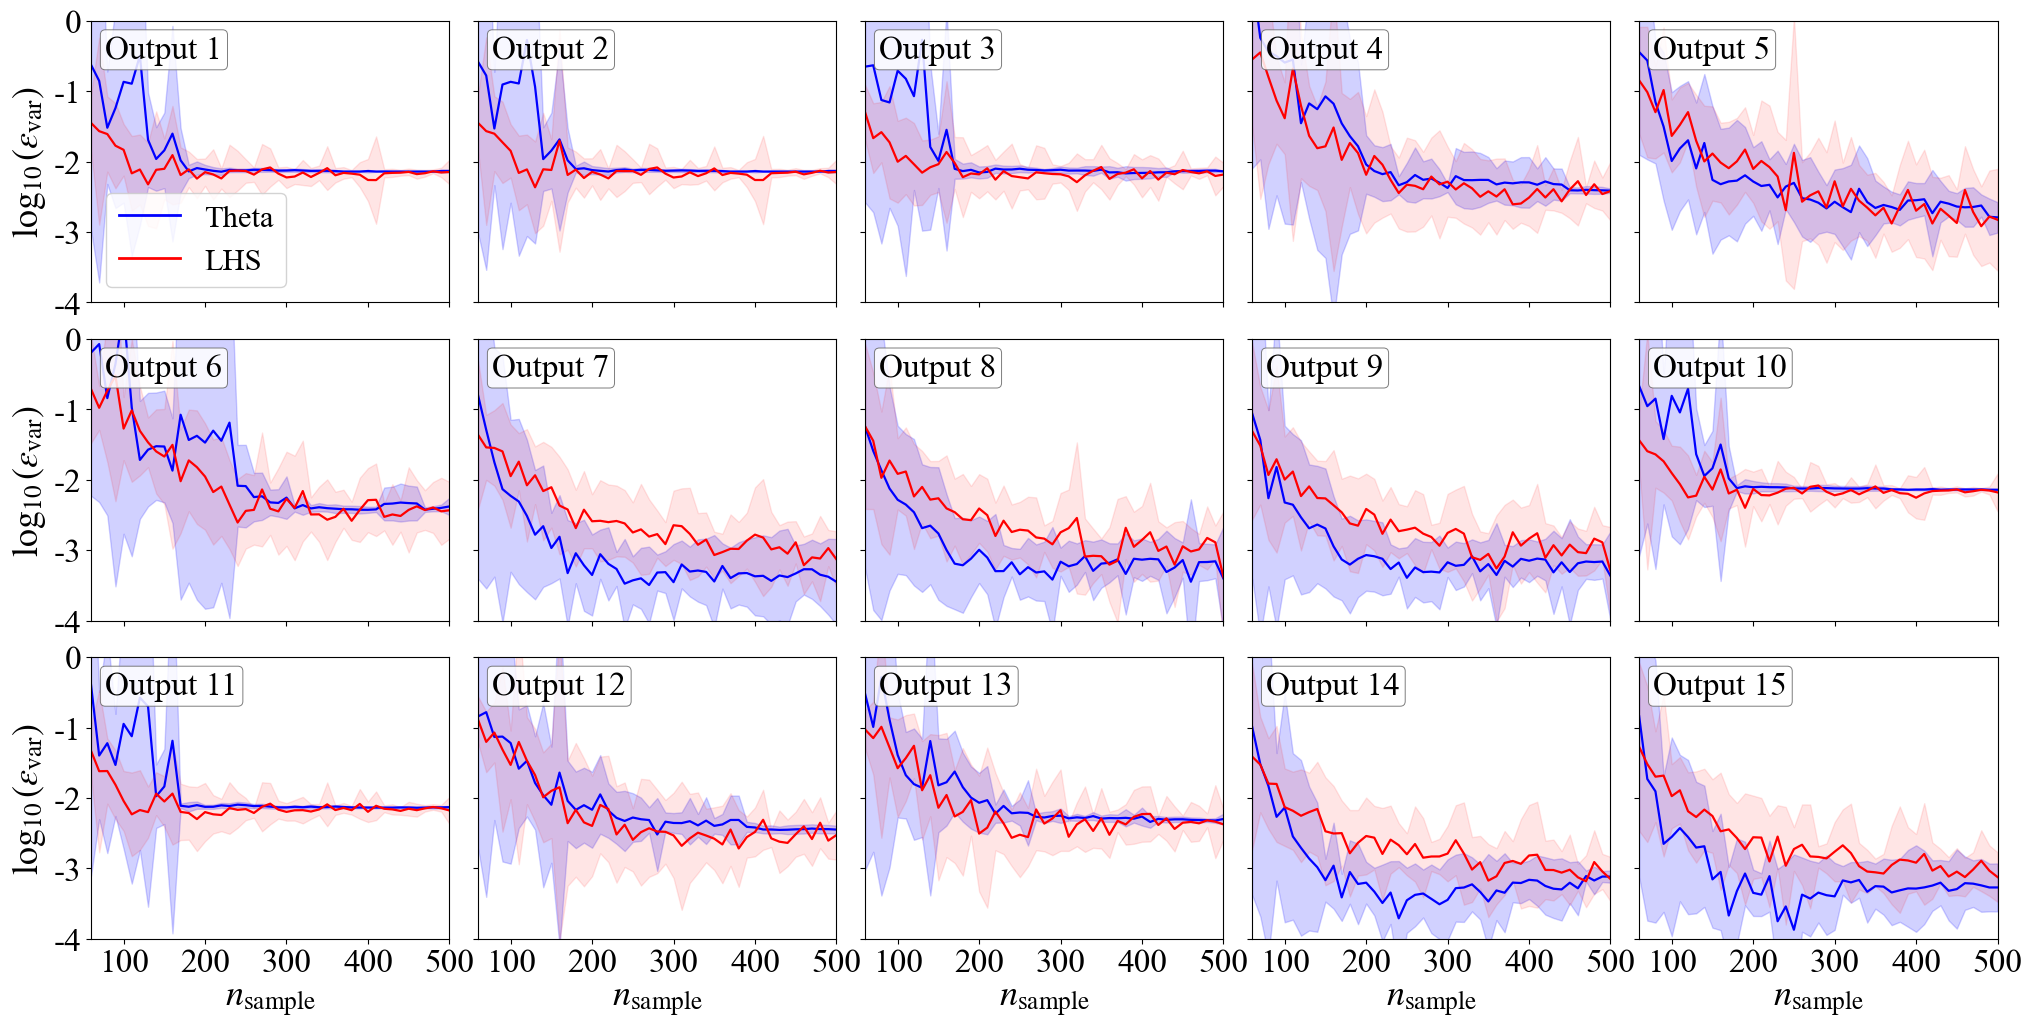

In [10]:
theta_variance_error = align_metric_histories(
    theta_results,
    plot_history,
    metric_key="eps_hist",
)

lhs_variance_error = align_metric_histories(
    lhs_results,
    plot_history,
    metric_key="eps_hist",
)

n_outputs = theta_variance_error.shape[2]

plot_metric_grid(
    x=plot_history,
    theta_values=theta_variance_error,
    lhs_values=lhs_variance_error,
    ylabel=r"$\log_{10}(\varepsilon_{\mathrm{var}})$",
    ylim_list=[(-4, 0)] * n_outputs,
    ytick_step_list=[1] * n_outputs,
    output_file="variance_error_grid.pdf",
)

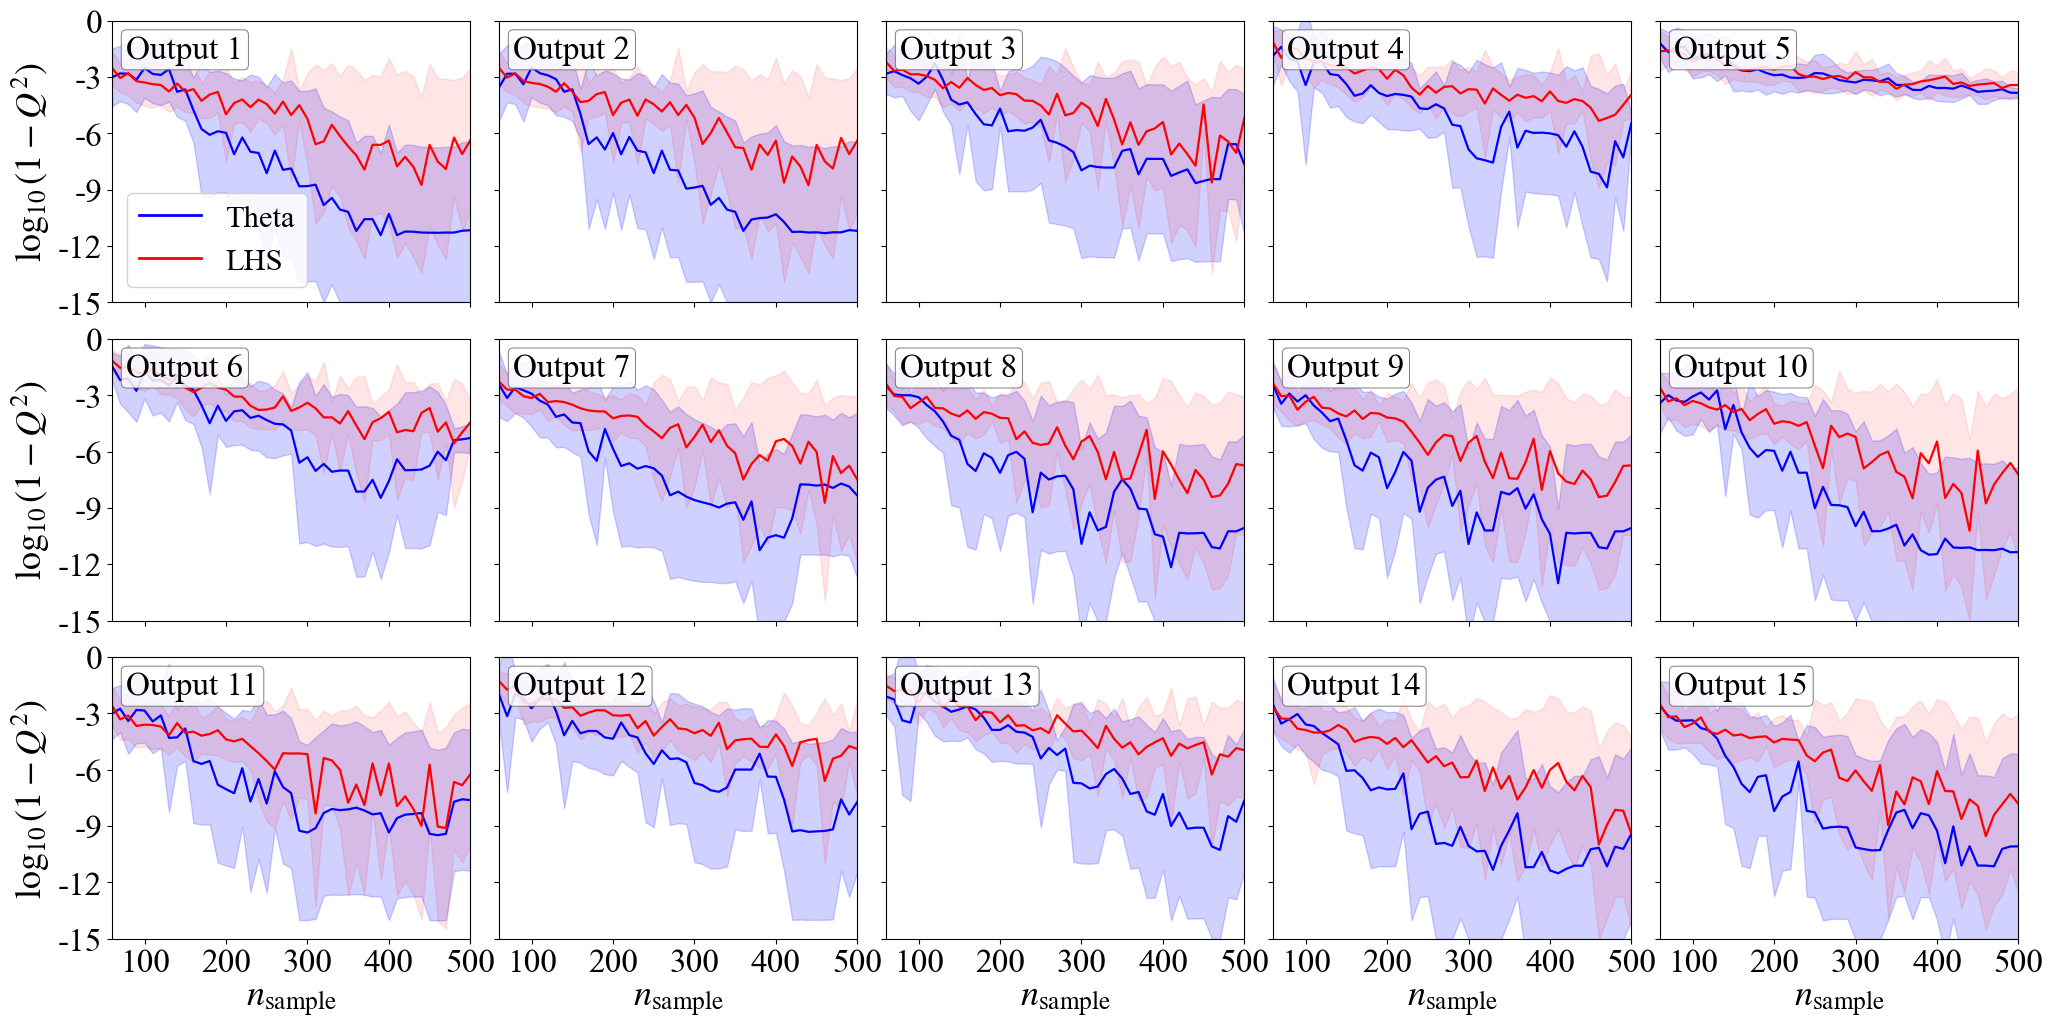

In [11]:
theta_loo = align_metric_histories(
    theta_results,
    plot_history,
    metric_key="one_minus_Q2_hist",
)

lhs_loo = align_metric_histories(
    lhs_results,
    plot_history,
    metric_key="one_minus_Q2_hist",
)

n_outputs = theta_loo.shape[2]

plot_metric_grid(
    x=plot_history,
    theta_values=theta_loo,
    lhs_values=lhs_loo,
    ylabel=r"$\log_{10}(1-Q^2)$",
    ylim_list=[(-15, 0)] * n_outputs,
    ytick_step_list=[3] * n_outputs,
    output_file="loo_error_grid.pdf",
)